## Introduction

Prepare a prototype of a machine learning model for Zyfra. The company develops efficiency solutions for heavy industry.

The model should predict the amount of gold recovered from gold ore. You have the data on extraction and purification.

The model will help to optimize the production and eliminate unprofitable parameters.

We are:

Preparing the data;
Performing data analysis;
Developing and training a model.


In [1]:
#RECOVERY = (concentrate*(feed - tails))/(feed*(concentrate - tails)) * 100%

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import plotly.express as px
import math
from scipy import stats as sts
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

## Prepare the data

In [3]:
# Loading dataframes
data_gr_train = pd.read_csv('datasets/gold_recovery_train.csv')
data_gr_test = pd.read_csv('datasets/gold_recovery_test.csv')
data_gr_full = pd.read_csv('datasets/gold_recovery_full.csv')

In [4]:
# Checking the data
display(data_gr_train)
display(data_gr_train.info())

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16855,2018-08-18 06:59:59,3.224920,11.356233,6.803482,46.713954,73.755150,8.769645,3.141541,10.403181,1.529220,...,23.031497,-501.167942,20.007571,-499.740028,18.006038,-499.834374,13.001114,-500.155694,20.007840,-501.296428
16856,2018-08-18 07:59:59,3.195978,11.349355,6.862249,46.866780,69.049291,8.897321,3.130493,10.549470,1.612542,...,22.960095,-501.612783,20.035660,-500.251357,17.998535,-500.395178,12.954048,-499.895163,19.968498,-501.041608
16857,2018-08-18 08:59:59,3.109998,11.434366,6.886013,46.795691,67.002189,8.529606,2.911418,11.115147,1.596616,...,23.015718,-501.711599,19.951231,-499.857027,18.019543,-500.451156,13.023431,-499.914391,19.990885,-501.518452
16858,2018-08-18 09:59:59,3.367241,11.625587,6.799433,46.408188,65.523246,8.777171,2.819214,10.463847,1.602879,...,23.024963,-501.153409,20.054122,-500.314711,17.979515,-499.272871,12.992404,-499.976268,20.013986,-500.625471


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


None

In [5]:
display(data_gr_test)
display(data_gr_test.info())

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5851,2017-12-31 19:59:59,173.957757,15.963399,8.070000,0.896701,1401.930554,-499.728848,1401.441445,-499.193423,1399.810313,...,13.995957,-500.157454,12.069155,-499.673279,7.977259,-499.516126,5.933319,-499.965973,8.987171,-499.755909
5852,2017-12-31 20:59:59,172.910270,16.002605,8.070000,0.896519,1447.075722,-494.716823,1448.851892,-465.963026,1443.890424,...,16.749781,-496.031539,13.365371,-499.122723,9.288553,-496.892967,7.372897,-499.942956,8.986832,-499.903761
5853,2017-12-31 21:59:59,171.135718,15.993669,8.070000,1.165996,1498.836182,-501.770403,1499.572353,-495.516347,1502.749213,...,19.994130,-499.791312,15.101425,-499.936252,10.989181,-498.347898,9.020944,-500.040448,8.982038,-497.789882
5854,2017-12-31 22:59:59,179.697158,15.438979,8.070000,1.501068,1498.466243,-500.483984,1497.986986,-519.200340,1496.569047,...,19.958760,-499.958750,15.026853,-499.723143,11.011607,-499.985046,9.009783,-499.937902,9.012660,-500.154284


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

None

In [6]:
display(data_gr_full)
display(data_gr_full.info())

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22711,2018-08-18 06:59:59,3.224920,11.356233,6.803482,46.713954,73.755150,8.769645,3.141541,10.403181,1.529220,...,23.031497,-501.167942,20.007571,-499.740028,18.006038,-499.834374,13.001114,-500.155694,20.007840,-501.296428
22712,2018-08-18 07:59:59,3.195978,11.349355,6.862249,46.866780,69.049291,8.897321,3.130493,10.549470,1.612542,...,22.960095,-501.612783,20.035660,-500.251357,17.998535,-500.395178,12.954048,-499.895163,19.968498,-501.041608
22713,2018-08-18 08:59:59,3.109998,11.434366,6.886013,46.795691,67.002189,8.529606,2.911418,11.115147,1.596616,...,23.015718,-501.711599,19.951231,-499.857027,18.019543,-500.451156,13.023431,-499.914391,19.990885,-501.518452
22714,2018-08-18 09:59:59,3.367241,11.625587,6.799433,46.408188,65.523246,8.777171,2.819214,10.463847,1.602879,...,23.024963,-501.153409,20.054122,-500.314711,17.979515,-499.272871,12.992404,-499.976268,20.013986,-500.625471


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


None

Everything here is a float64 value which makes sense since these are all steps in the same process and each step would represent amounts of material. There appears to be null values so I will further investigate those along with checking for duplicate values.

In [7]:
# Checking rougher.output.recovery
C = data_gr_full['rougher.output.concentrate_au']
F = data_gr_full['rougher.input.feed_au']
T = data_gr_full['rougher.output.tail_au']

# Avoid division by zero
valid_entries = (F != T) & (C != T)

# Calculated recovery
calculated_recovery = (C * (F - T) / (F * (C - T))) * 100
c_r = calculated_recovery[valid_entries]

true_recovery = data_gr_full['rougher.output.recovery'][valid_entries]

# Remove null values & calculated_recovery
mask = true_recovery.notna() & calculated_recovery.notna()

# Calculate MAE
abs_mean_difference = (calculated_recovery[mask] - true_recovery[mask]).abs().mean()

print(f"Mean Absolute Difference: {abs_mean_difference:.6f}")


Mean Absolute Difference: 0.000000


The rougher.output.recovery appears to be calculating correctly.

In [8]:
# Checking for all features missing from the test set
test_missing = list(set(data_gr_train.columns) - set(data_gr_test.columns))
display(data_gr_train[test_missing].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   rougher.calculation.floatbank10_sulfate_to_au_feed  16833 non-null  float64
 1   rougher.output.tail_sol                             14611 non-null  float64
 2   final.output.concentrate_au                         16789 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   rougher.output.concentrate_pb                       16778 non-null  float64
 5   rougher.output.concentrate_sol                      16698 non-null  float64
 6   rougher.calculation.sulfate_to_au_concentrate       16833 non-null  float64
 7   secondary_cleaner.output.tail_pb                    16764 non-null  float64
 8   secondary_cleaner.output.tail_au                    16778 non-null  float64


None

The features that are missing from the test data appears to be the outputs and corresponding calculations. I will need to follow up and do further reasearch but this may be due to the fact that the info is also contained in the inputs for the next steps. For the time being, removing the missing columns from the training dataframe to have the consistent and usable for models.

In [9]:
# Removing the missing columns/features.
# data_gr_train = data_gr_train.drop(columns=test_missing)
# Undoing the removal of the training columns. They are needed for the training of the models.

In [10]:
# Checking for dupes
dupe_train = data_gr_train.duplicated()
print(data_gr_train[dupe_train])

dupe_test = data_gr_test.duplicated()
print(data_gr_test[dupe_test])

dupe_full = data_gr_full.duplicated()
print(data_gr_full[dupe_full])

Empty DataFrame
Columns: [date, final.output.concentrate_ag, final.output.concentrate_pb, final.output.concentrate_sol, final.output.concentrate_au, final.output.recovery, final.output.tail_ag, final.output.tail_pb, final.output.tail_sol, final.output.tail_au, primary_cleaner.input.sulfate, primary_cleaner.input.depressant, primary_cleaner.input.feed_size, primary_cleaner.input.xanthate, primary_cleaner.output.concentrate_ag, primary_cleaner.output.concentrate_pb, primary_cleaner.output.concentrate_sol, primary_cleaner.output.concentrate_au, primary_cleaner.output.tail_ag, primary_cleaner.output.tail_pb, primary_cleaner.output.tail_sol, primary_cleaner.output.tail_au, primary_cleaner.state.floatbank8_a_air, primary_cleaner.state.floatbank8_a_level, primary_cleaner.state.floatbank8_b_air, primary_cleaner.state.floatbank8_b_level, primary_cleaner.state.floatbank8_c_air, primary_cleaner.state.floatbank8_c_level, primary_cleaner.state.floatbank8_d_air, primary_cleaner.state.floatbank8_d_le

No dupes to worry about. Moving on checking null values.

In [11]:
# Checking for nulls
display(data_gr_train.isnull().sum().to_string())

'date                                                     0\nfinal.output.concentrate_ag                             72\nfinal.output.concentrate_pb                             72\nfinal.output.concentrate_sol                           370\nfinal.output.concentrate_au                             71\nfinal.output.recovery                                 1521\nfinal.output.tail_ag                                    66\nfinal.output.tail_pb                                   183\nfinal.output.tail_sol                                  145\nfinal.output.tail_au                                    66\nprimary_cleaner.input.sulfate                         1307\nprimary_cleaner.input.depressant                      1262\nprimary_cleaner.input.feed_size                          0\nprimary_cleaner.input.xanthate                         985\nprimary_cleaner.output.concentrate_ag                   82\nprimary_cleaner.output.concentrate_pb                  358\nprimary_cleaner.output.concentrate_sol 

In [12]:
display(data_gr_test.isnull().sum().to_string())

'date                                            0\nprimary_cleaner.input.sulfate                 302\nprimary_cleaner.input.depressant              284\nprimary_cleaner.input.feed_size                 0\nprimary_cleaner.input.xanthate                166\nprimary_cleaner.state.floatbank8_a_air         16\nprimary_cleaner.state.floatbank8_a_level       16\nprimary_cleaner.state.floatbank8_b_air         16\nprimary_cleaner.state.floatbank8_b_level       16\nprimary_cleaner.state.floatbank8_c_air         16\nprimary_cleaner.state.floatbank8_c_level       16\nprimary_cleaner.state.floatbank8_d_air         16\nprimary_cleaner.state.floatbank8_d_level       16\nrougher.input.feed_ag                          16\nrougher.input.feed_pb                          16\nrougher.input.feed_rate                        40\nrougher.input.feed_size                        22\nrougher.input.feed_sol                         67\nrougher.input.feed_au                          16\nrougher.input.floatbank10_sulf

In [13]:
display(data_gr_full.isnull().sum().to_string())

'date                                                     0\nfinal.output.concentrate_ag                             89\nfinal.output.concentrate_pb                             87\nfinal.output.concentrate_sol                           385\nfinal.output.concentrate_au                             86\nfinal.output.recovery                                 1963\nfinal.output.tail_ag                                    83\nfinal.output.tail_pb                                   200\nfinal.output.tail_sol                                  271\nfinal.output.tail_au                                    81\nprimary_cleaner.input.sulfate                         1609\nprimary_cleaner.input.depressant                      1546\nprimary_cleaner.input.feed_size                          0\nprimary_cleaner.input.xanthate                        1151\nprimary_cleaner.output.concentrate_ag                   98\nprimary_cleaner.output.concentrate_pb                  448\nprimary_cleaner.output.concentrate_sol 

I will try dropping the null values. If this doesn't affect the data too much we can work with that. If not I will have to use mean values. One of the issues I have with using mean values is due to the fact that you may have mean values that are higher than possible values for the step of the process. But it may be something we can live with.

In [14]:
train_cleaned = data_gr_train.dropna()
print(train_cleaned.info)

<bound method DataFrame.info of                       date  final.output.concentrate_ag  \
0      2016-01-15 00:00:00                     6.055403   
1      2016-01-15 01:00:00                     6.029369   
2      2016-01-15 02:00:00                     6.055926   
3      2016-01-15 03:00:00                     6.047977   
4      2016-01-15 04:00:00                     6.148599   
...                    ...                          ...   
16855  2018-08-18 06:59:59                     3.224920   
16856  2018-08-18 07:59:59                     3.195978   
16857  2018-08-18 08:59:59                     3.109998   
16858  2018-08-18 09:59:59                     3.367241   
16859  2018-08-18 10:59:59                     3.598375   

       final.output.concentrate_pb  final.output.concentrate_sol  \
0                         9.889648                      5.507324   
1                         9.968944                      5.257781   
2                        10.213995                     

In [15]:
test_cleaned = data_gr_test.dropna()
print(test_cleaned.info)

<bound method DataFrame.info of                      date  primary_cleaner.input.sulfate  \
0     2016-09-01 00:59:59                     210.800909   
1     2016-09-01 01:59:59                     215.392455   
2     2016-09-01 02:59:59                     215.259946   
3     2016-09-01 03:59:59                     215.336236   
4     2016-09-01 04:59:59                     199.099327   
...                   ...                            ...   
5851  2017-12-31 19:59:59                     173.957757   
5852  2017-12-31 20:59:59                     172.910270   
5853  2017-12-31 21:59:59                     171.135718   
5854  2017-12-31 22:59:59                     179.697158   
5855  2017-12-31 23:59:59                     181.556856   

      primary_cleaner.input.depressant  primary_cleaner.input.feed_size  \
0                            14.993118                         8.080000   
1                            14.987471                         8.080000   
2                     

In [16]:
full_cleaned = data_gr_full.dropna()
print(full_cleaned.info)

<bound method DataFrame.info of                       date  final.output.concentrate_ag  \
0      2016-01-15 00:00:00                     6.055403   
1      2016-01-15 01:00:00                     6.029369   
2      2016-01-15 02:00:00                     6.055926   
3      2016-01-15 03:00:00                     6.047977   
4      2016-01-15 04:00:00                     6.148599   
...                    ...                          ...   
22711  2018-08-18 06:59:59                     3.224920   
22712  2018-08-18 07:59:59                     3.195978   
22713  2018-08-18 08:59:59                     3.109998   
22714  2018-08-18 09:59:59                     3.367241   
22715  2018-08-18 10:59:59                     3.598375   

       final.output.concentrate_pb  final.output.concentrate_sol  \
0                         9.889648                      5.507324   
1                         9.968944                      5.257781   
2                        10.213995                     

I am losing about a quarter of my data from the full and train sets but less so on my test. If this affects the outcome I can comeback and redo this by fill in null values with the means.,

## Analyze the data

In [17]:
# Investigating the concentrations of Au, Ag, Pb.
gold_stages = [
    'rougher.input.feed_au',     # Initial concentration
    'rougher.output.concentrate_au',  # After rougher
    'final.output.concentrate_au'     # Final concentration
]
silver_stages = [
    'rougher.input.feed_ag',     # Initial concentration
    'rougher.output.concentrate_ag',  # After rougher
    'final.output.concentrate_ag'     # Final concentration
]
lead_stages = [
    'rougher.input.feed_pb',     # Initial concentration
    'rougher.output.concentrate_pb',  # After rougher
    'final.output.concentrate_pb'     # Final concentration
]

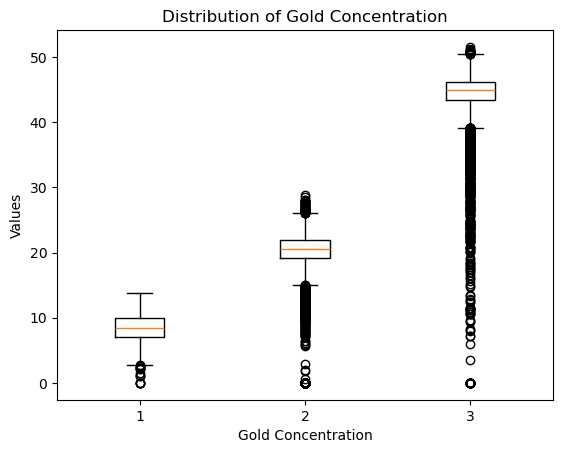

In [18]:
# Graphing gold
plt.boxplot(full_cleaned[gold_stages])
plt.xlabel('Gold Concentration')
plt.ylabel('Values')
plt.title('Distribution of Gold Concentration')
plt.show()


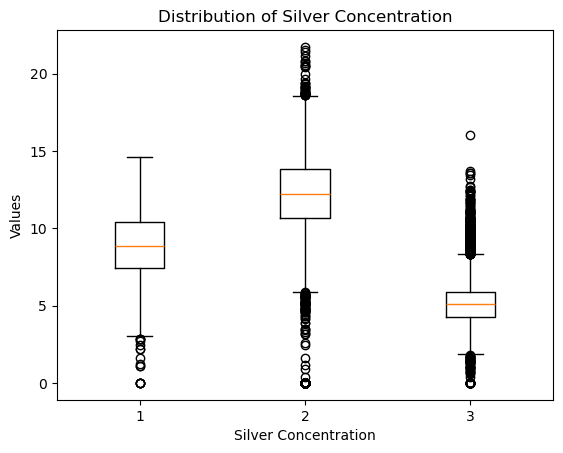

In [19]:
# Graphing silver
plt.boxplot(full_cleaned[silver_stages])
plt.xlabel('Silver Concentration')
plt.ylabel('Values')
plt.title('Distribution of Silver Concentration')
plt.show()

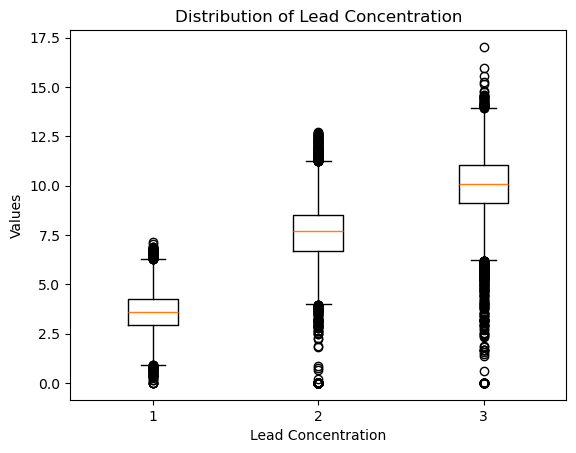

In [20]:
# Graphing lead
plt.boxplot(full_cleaned[lead_stages])
plt.xlabel('Lead Concentration')
plt.ylabel('Values')
plt.title('Distribution of Lead Concentration')
plt.show()

As the materials go through the process we see that the rougher process removes other impurities and all through concentrations go up. As we move towards the final output, we see that silver goes down while lead and gold go up. This is most likely due to the fact that silver is lighter than both lead and gold.

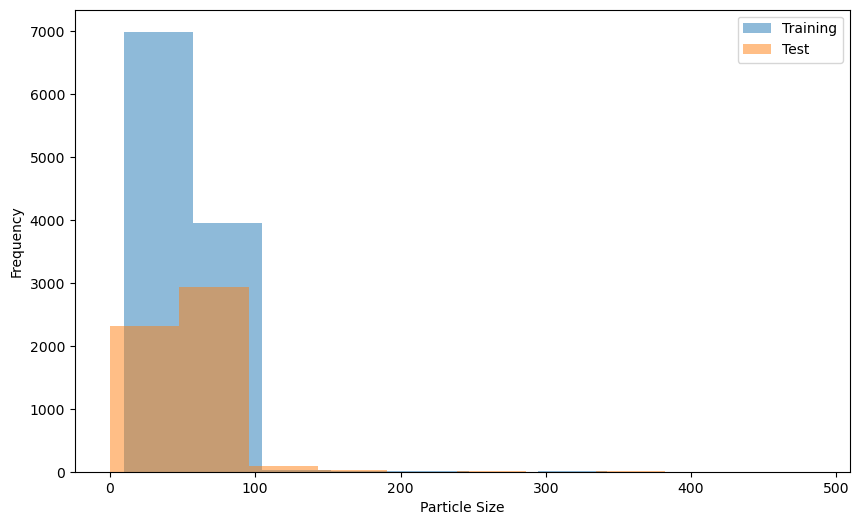

In [21]:
# Comparing training and test sets
plt.figure(figsize=(10, 6))
plt.hist(train_cleaned['rougher.input.feed_size'], alpha=0.5, label='Training')
plt.hist(test_cleaned['rougher.input.feed_size'], alpha=0.5, label='Test')
plt.xlabel('Particle Size')
plt.ylabel('Frequency')
plt.legend()

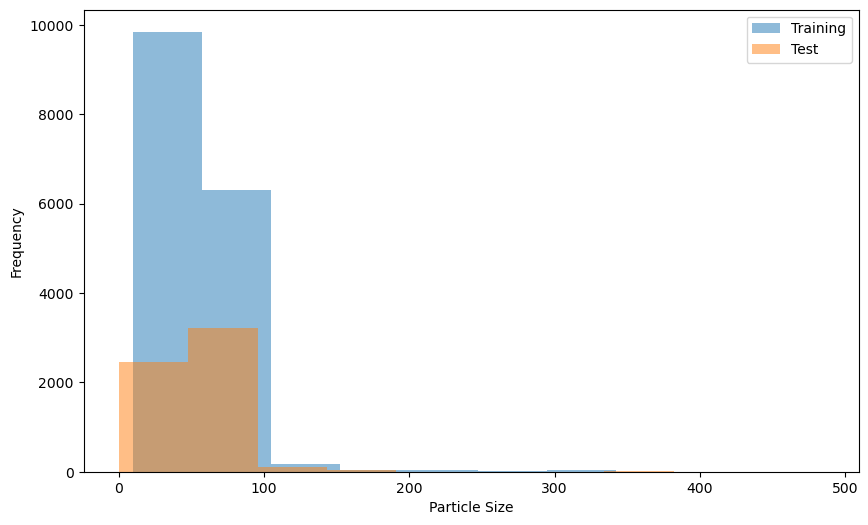

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(data_gr_train['rougher.input.feed_size'], alpha=0.5, label='Training')
plt.hist(data_gr_test['rougher.input.feed_size'], alpha=0.5, label='Test')
plt.xlabel('Particle Size')
plt.ylabel('Frequency')
plt.legend()

In [23]:
display(train_cleaned['rougher.input.feed_size'].describe()) 
display(test_cleaned['rougher.input.feed_size'].describe())


count    11017.000000
mean        57.215128
std         18.913146
min          9.659576
25%         48.397242
50%         53.843359
75%         61.461770
max        484.967466
Name: rougher.input.feed_size, dtype: float64

count    5383.000000
mean       56.338644
std        21.836788
min         0.046369
25%        43.913766
50%        50.924232
75%        62.364984
max       477.445473
Name: rougher.input.feed_size, dtype: float64

In [24]:
display(data_gr_train['rougher.input.feed_size'].describe()) 
display(data_gr_test['rougher.input.feed_size'].describe())

count    16443.000000
mean        58.676444
std         23.922591
min          9.659576
25%         47.575879
50%         54.104257
75%         65.051064
max        484.967466
Name: rougher.input.feed_size, dtype: float64

count    5834.000000
mean       55.937535
std        22.724254
min         0.046369
25%        43.890852
50%        50.002004
75%        61.638434
max       477.445473
Name: rougher.input.feed_size, dtype: float64

It looks like the  datasets are relatively close and perhaps the model evaluation is correct. The test set shows slightly more variablity which is expected since it is a smaller set.

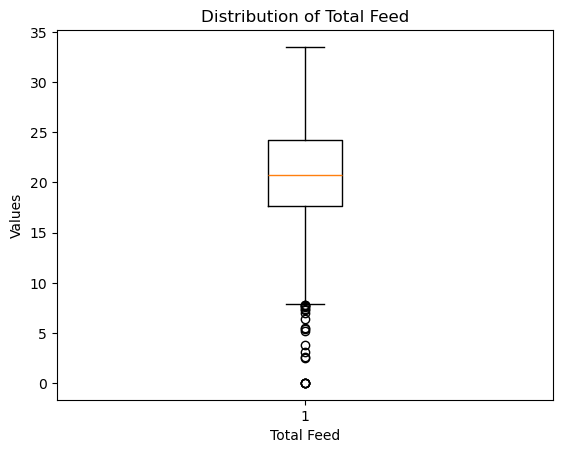

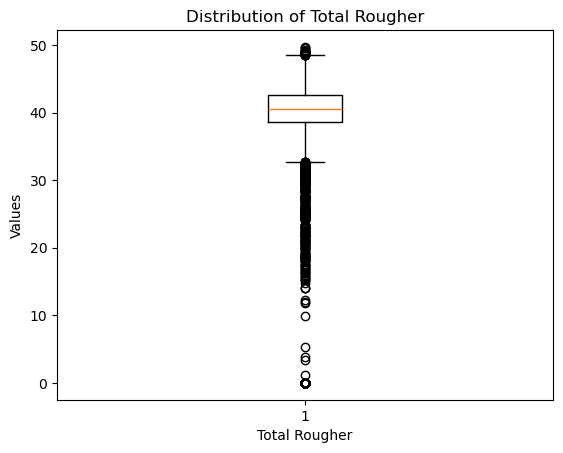

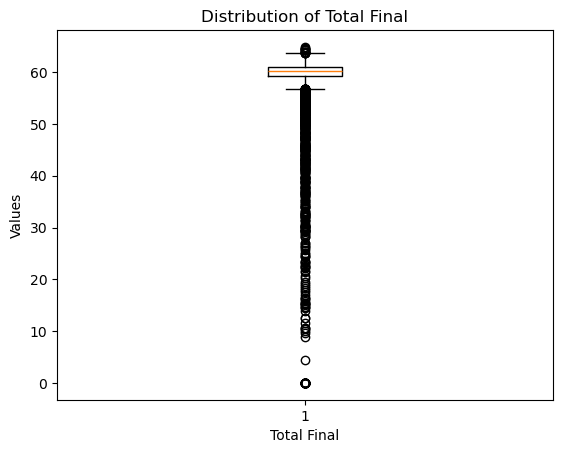

In [25]:
# Checking for anomalies
total_feed = full_cleaned['rougher.input.feed_ag'] + full_cleaned['rougher.input.feed_au'] + full_cleaned['rougher.input.feed_pb']
total_rougher = full_cleaned['rougher.output.concentrate_ag'] + full_cleaned['rougher.output.concentrate_au'] + full_cleaned['rougher.output.concentrate_pb']
total_final = full_cleaned['final.output.concentrate_ag'] + full_cleaned['final.output.concentrate_au'] + full_cleaned['final.output.concentrate_pb']

plt.boxplot(total_feed)
plt.xlabel('Total Feed')
plt.ylabel('Values')
plt.title('Distribution of Total Feed')
plt.show()
plt.boxplot(total_rougher)
plt.xlabel('Total Rougher')
plt.ylabel('Values')
plt.title('Distribution of Total Rougher')
plt.show()
plt.boxplot(total_final)
plt.xlabel('Total Final')
plt.ylabel('Values')
plt.title('Distribution of Total Final')
plt.show()

This was checked against a data set with dropped null values. As the material moves through the process the concentration generally goes higher and gets closer to 60%. I noticed that there are many outliers at 0 and extremely low. I'm not sure if this is a case of bad data or bad feed going through the process. Needs further investigations.

## Building the model

In [26]:
# Function to calculate sMAPE and final sMAPE value


def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Avoid division by zero
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return 100 * np.mean(numerator / denominator)

def calculate_final_smape(true_rougher, pred_rougher, true_final, pred_final):
    """
    Calculate the final sMAPE value for both rougher and final recovery predictions
    
    Parameters:
    y_true_rougher: actual rougher recovery values
    y_pred_rougher: predicted rougher recovery values
    y_true_final: actual final recovery values
    y_pred_final: predicted final recovery values
    
    Returns:
    float: final sMAPE value
    """
    # Calculate sMAPE for both recoveries
    smape_rougher = smape(true_rougher, pred_rougher)
    smape_final = smape(true_final, pred_final)
    
    # Calculate final metric
    final_smape = (smape_rougher + smape_final) / 2
    
    return final_smape

In [27]:
display(data_gr_train.info())
display(train_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


None

<class 'pandas.core.frame.DataFrame'>
Index: 11017 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                11017 non-null  object 
 1   final.output.concentrate_ag                         11017 non-null  float64
 2   final.output.concentrate_pb                         11017 non-null  float64
 3   final.output.concentrate_sol                        11017 non-null  float64
 4   final.output.concentrate_au                         11017 non-null  float64
 5   final.output.recovery                               11017 non-null  float64
 6   final.output.tail_ag                                11017 non-null  float64
 7   final.output.tail_pb                                11017 non-null  float64
 8   final.output.tail_sol                               11017 non-null  float64
 9   

None

In [28]:
# Reviewer's code 2

full_cleaned.shape

(16094, 87)

In [29]:
# Setting up features and targets
# full_cleaned1 = full_cleaned.copy()
# full_cleaned1['date'] = pd.to_datetime(full_cleaned1['date'], format='%Y-%m-%d %H:%M:%S')
# full_cleaned1['year'] = full_cleaned1['date'].dt.year
# full_cleaned1['month'] = full_cleaned1['date'].dt.month
# full_cleaned1['day'] = full_cleaned1['date'].dt.day
# full_cleaned1['hour'] = full_cleaned1['date'].dt.hour
# full_cleaned1['day_of_week'] = full_cleaned1['date'].dt.dayofweek
# full_cleaned1 = full_cleaned1.drop(columns=['date'])

#train_cleaned['date'] = pd.to_datetime(train_cleaned['date'])  # Ensure it's in datetime format
train_cleaned.set_index('date', inplace=True)

#test_cleaned['date'] = pd.to_datetime(test_cleaned['date'])  # Ensure it's in datetime format
test_cleaned.set_index('date', inplace=True)

full_cleaned.set_index('date', inplace=True)

target_rougher = train_cleaned['rougher.output.recovery'].reset_index(drop=True)
target_final = train_cleaned['final.output.recovery'].reset_index(drop=True)

features = test_cleaned.columns.values
features_train = train_cleaned[features].reset_index(drop=True)

features_test = test_cleaned[features].reset_index(drop=True)
# features = full_cleaned1.drop(['rougher.output.recovery','final.output.recovery'], axis=1)

#target_rougher = full_cleaned1['rougher.output.recovery']

#target_final = full_cleaned1['final.output.recovery']

# features_train_rougher, features_test_rougher, target_train_rougher, target_test_rougher = train_test_split(
#    features, target_rougher, test_size=0.2, random_state=12345)
features_train_rougher, features_valid_rougher, target_train_rougher, target_valid_rougher = train_test_split(features_train, target_rougher, test_size=0.25, random_state=12345)

# features_train_final, features_test_final, target_train_final, target_test_final = train_test_split(
#     features, target_final, test_size=0.25, random_state=12345)
features_train_final, features_valid_final, target_train_final, target_valid_final = train_test_split(features_train, target_final, test_size=0.25, random_state=12345)

In [30]:
# Training a Linear regression model.
model = LinearRegression()# initialize model constructor
model.fit(features_train_rougher, target_train_rougher) # train model on training set
predictions_rougher1 = model.predict(features_valid_rougher) # get model predictions on validation set

model.fit(features_train_final, target_train_final) # train model on training set
predictions_final1 = model.predict(features_valid_final) # get model predictions on validation set

lr_final_smape = calculate_final_smape(target_valid_rougher, predictions_rougher1, target_valid_final, predictions_final1)
print(lr_final_smape)

8.064455003699301


In [31]:
# Running again with random forest.
model2 = RandomForestRegressor(n_estimators=500, max_depth=None, random_state=12345, min_samples_split=3)
model2.fit(features_train_rougher, target_train_rougher)
predictions_rough2 = model.predict(features_valid_rougher)
    
model2.fit(features_train_final, target_train_final)
predictions_final2 = model2.predict(features_valid_final)

rf_final_smape = calculate_final_smape(target_valid_rougher, predictions_rough2, target_valid_final, predictions_final2)
print(rf_final_smape)

15.74856463296814


In [32]:
# Tuning hyperparameters
# Trying RandomSearchCV
param_grid = {
    'n_estimators': [50, 75, 100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]}

rf_rougher = RandomForestRegressor(random_state=12345)
smape_scorer = make_scorer(smape, greater_is_better=False)
random_search = RandomizedSearchCV(
    estimator=rf_rougher, param_distributions=param_grid, 
    scoring=smape_scorer, cv=5, n_iter=10, n_jobs=-1, random_state=12345
)

random_search.fit(features_train_rougher, target_train_rougher)
best_rougher = random_search.best_params_
print(best_rougher)

{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}


In [33]:
random_search = RandomizedSearchCV(
    estimator=rf_rougher, param_distributions=param_grid, 
    scoring=smape_scorer, cv=5, n_iter=10, n_jobs=-1, random_state=12345
)

random_search.fit(features_train_final, target_train_final)
best_final = random_search.best_params_
print(best_final)

{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}


In [34]:
model3 = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=12345, min_samples_split=5)
model3.fit(features_train_rougher, target_train_rougher)
predictions_rough2 = model3.predict(features_valid_rougher)

model4 = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=12345, min_samples_split=5)
model4.fit(features_train_final, target_train_final) 
predictions_final2 = model4.predict(features_valid_final)

rf_final_smape = calculate_final_smape(target_valid_rougher, predictions_rough2, target_valid_final, predictions_final2)
print(rf_final_smape)

5.9936395603302834


With the tuning, I have two models that will get RandomForestRegressor down to 5.9943%

In [35]:
# Running a final test
model3 = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=12345, min_samples_split=5)
model3.fit(features_train_rougher, target_train_rougher)
predictions_rough2 = model3.predict(features_test)

model4 = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=12345, min_samples_split=5)
model4.fit(features_train_final, target_train_final) 
predictions_final2 = model4.predict(features_test)

# Target columnns do not exist in test set. Grabbing them from
target_test_rougher = full_cleaned[['rougher.output.recovery']].reindex(test_cleaned.index).values.flatten()
target_test_final = full_cleaned[['final.output.recovery']].reindex(test_cleaned.index).values.flatten()

mean_rougher = np.nanmean(target_test_rougher)
mean_final = np.nanmean(target_test_final)

target_test_rougher = np.where(np.isnan(target_test_rougher), mean_rougher, target_test_rougher)
target_test_final = np.where(np.isnan(target_test_final), mean_final, target_test_final)

rf_final_smape = calculate_final_smape(target_test_rougher, predictions_rough2, target_test_final, predictions_final2)
print(rf_final_smape)

11.13545206489865


In [36]:
# Get feature importance
importances = model3.feature_importances_
feature_names = features_train_rougher.columns

# Create a DataFrame and sort it
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Print ranked feature importance
print(importance_df.head(5))


                                     Feature  Importance
18         rougher.input.floatbank10_sulfate    0.108674
6     primary_cleaner.state.floatbank8_b_air    0.098704
12                     rougher.input.feed_ag    0.087033
20         rougher.input.floatbank11_sulfate    0.062185
48  secondary_cleaner.state.floatbank5_b_air    0.054664


In [37]:
importances = model4.feature_importances_
feature_names = features_train_final.columns

# Create a DataFrame and sort it
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Print ranked feature importance
print(importance_df.head(5))

                                     Feature  Importance
12                     rougher.input.feed_ag    0.185317
0              primary_cleaner.input.sulfate    0.075691
34  secondary_cleaner.state.floatbank2_a_air    0.043227
1           primary_cleaner.input.depressant    0.030910
19        rougher.input.floatbank10_xanthate    0.029771


## Conclusion

We were tasked to look at making a model for predicting gold recovery. 

We tested a linear regression model and a random forest. Initially the linear regression returned better results but after tuning the random forest was more promising.

The current best model I worked out was a Random Forest model. It returned a 11.137607128939571 for the final sMAPE when checked against final test set. 

Since there are two stages that we are looking at there are two models that will produce better results in producing rougher and final values. For example the top 5 features for rougher are:
                                     Feature  Importance
18         rougher.input.floatbank10_sulfate    0.109039
6     primary_cleaner.state.floatbank8_b_air    0.098863
12                     rougher.input.feed_ag    0.086533
20         rougher.input.floatbank11_sulfate    0.062698
48  secondary_cleaner.state.floatbank5_b_air    0.054942


And the final are:
                                     Feature  Importance
12                     rougher.input.feed_ag    0.185213
0              primary_cleaner.input.sulfate    0.075835
34  secondary_cleaner.state.floatbank2_a_air    0.043411
1           primary_cleaner.input.depressant    0.031040
19        rougher.input.floatbank10_xanthate    0.029426

I ran the test several times and had to re do my methods and test steps. 

I recommend this is method is used moving forward.